# House Price Prediction
**Name:** Ooha Chekuri

A regression project to predict house prices based on property features and identify the most influential factors.

---
## Task 1 — Data Loading & Exploration

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported successfully.')

Libraries imported successfully.


In [2]:
# Load the CSV file
df = pd.read_csv('Housing.csv')

# Display first 10 rows
print('First 10 rows of the dataset:')
display(df.head(10))

First 10 rows of the dataset:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
# Check shape (rows, columns)
print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Dataset shape: (545, 13)
Rows: 545
Columns: 13


In [4]:
# Identify target and features
print('Target column: Price')
print('\nFeature columns:')
for col in df.columns:
    if col != 'price':
        print(f'  - {col}')

Target column: Price

Feature columns:
  - area
  - bedrooms
  - bathrooms
  - stories
  - mainroad
  - guestroom
  - basement
  - hotwaterheating
  - airconditioning
  - parking
  - prefarea
  - furnishingstatus


In [5]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

if df.isnull().sum().sum() == 0:
    print('\nNo missing values found in the dataset.')

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

No missing values found in the dataset.


---
## Task 2 — Data Cleaning

In [6]:
# Check for duplicate rows
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'Removed {dupes} duplicate(s). New shape: {df.shape}')

Duplicate rows: 0


In [7]:
# Convert categorical yes/no columns to numeric (0/1)
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

print('Binary columns encoded (yes=1, no=0):')
print(df[binary_cols].head())

Binary columns encoded (yes=1, no=0):
   mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea
0         1          0         0                0                1         1
1         1          0         0                0                1         0
2         1          0         1                0                0         1
3         1          0         1                0                1         1
4         1          1         1                0                1         0


In [8]:
# One-hot encode furnishingstatus
print('Unique furnishingstatus values:', df['furnishingstatus'].unique())
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=False, dtype=int)
print('\nAfter one-hot encoding:')
display(df.head())

Unique furnishingstatus values: ['furnished' 'semi-furnished' 'unfurnished']

After one-hot encoding:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


In [9]:
# All columns are now numeric — confirm dtypes
print('Data types after cleaning:')
print(df.dtypes)
print(f'\nFinal shape: {df.shape}')

Data types after cleaning:
price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_furnished         int32
furnishingstatus_semi-furnished    int32
furnishingstatus_unfurnished       int32
dtype: object

Final shape: (545, 15)


---
## Task 3 — Model Building

In [10]:
# Separate features and target
X = df.drop('price', axis=1)
y = df['price']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

Training set: (436, 14)
Test set: (109, 14)


In [11]:
# ---- Linear Regression ----
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print('=== Linear Regression Performance ===')
print(f'MAE  : {mae_lr:,.2f}')
print(f'RMSE : {rmse_lr:,.2f}')
print(f'R²   : {r2_lr:.4f}')

=== Linear Regression Performance ===
MAE  : 970,043.40
RMSE : 1,324,506.96
R²   : 0.6529


In [12]:
# ---- Random Forest Regressor ----
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print('=== Random Forest Regressor Performance ===')
print(f'MAE  : {mae_rf:,.2f}')
print(f'RMSE : {rmse_rf:,.2f}')
print(f'R²   : {r2_rf:.4f}')

=== Random Forest Regressor Performance ===
MAE  : 1,019,527.55
RMSE : 1,400,219.42
R²   : 0.6121


In [13]:
# Compare both models
comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Linear Regression': [f'{mae_lr:,.0f}', f'{rmse_lr:,.0f}', f'{r2_lr:.4f}'],
    'Random Forest': [f'{mae_rf:,.0f}', f'{rmse_rf:,.0f}', f'{r2_rf:.4f}']
})
print('Model Comparison:')
display(comparison)

Model Comparison:


,Metric,Linear Regression,Random Forest
0,MAE,"970,043","1,019,528"
1,RMSE,"1,324,507","1,400,219"
2,R² Score,0.6529,0.6121


---
## Task 4 — Visualization (Minimum 3 Charts)

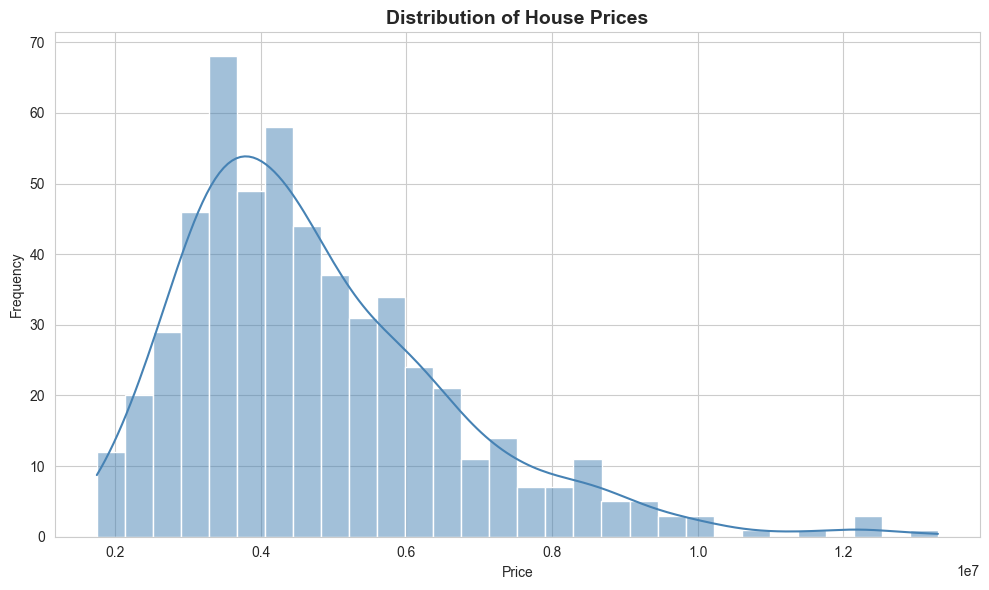

Chart 1 saved → charts/chart1_price_distribution.png


In [14]:
# Chart 1: Histogram of House Prices
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()
print('Chart 1 saved → charts/chart1_price_distribution.png')

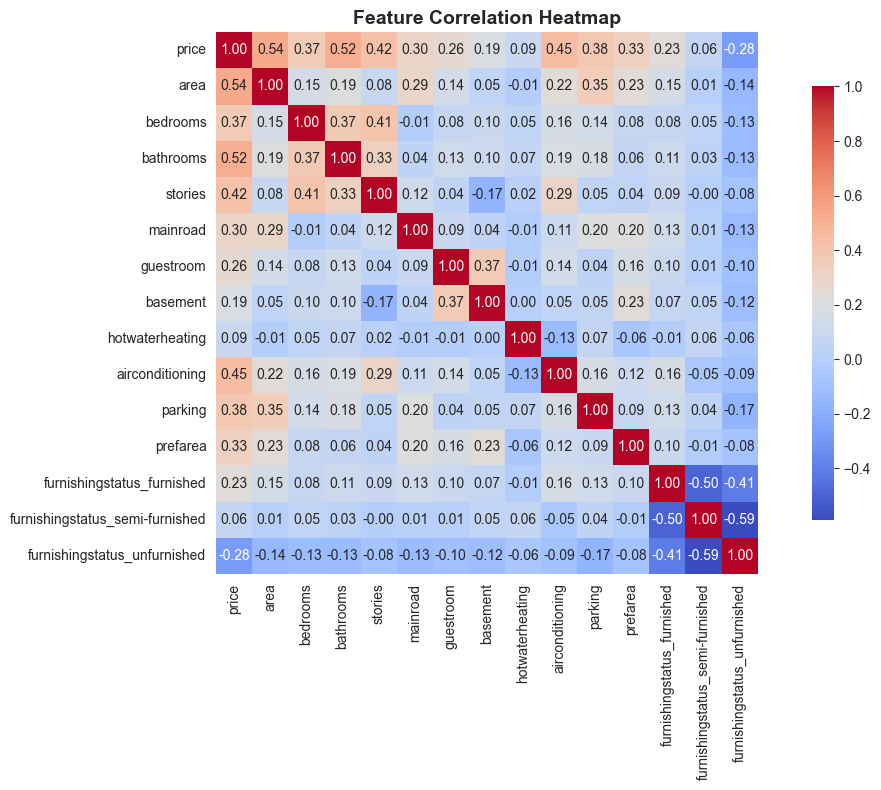

Chart 2 saved → charts/chart2_correlation_heatmap.png


In [15]:
# Chart 2: Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()
print('Chart 2 saved → charts/chart2_correlation_heatmap.png')

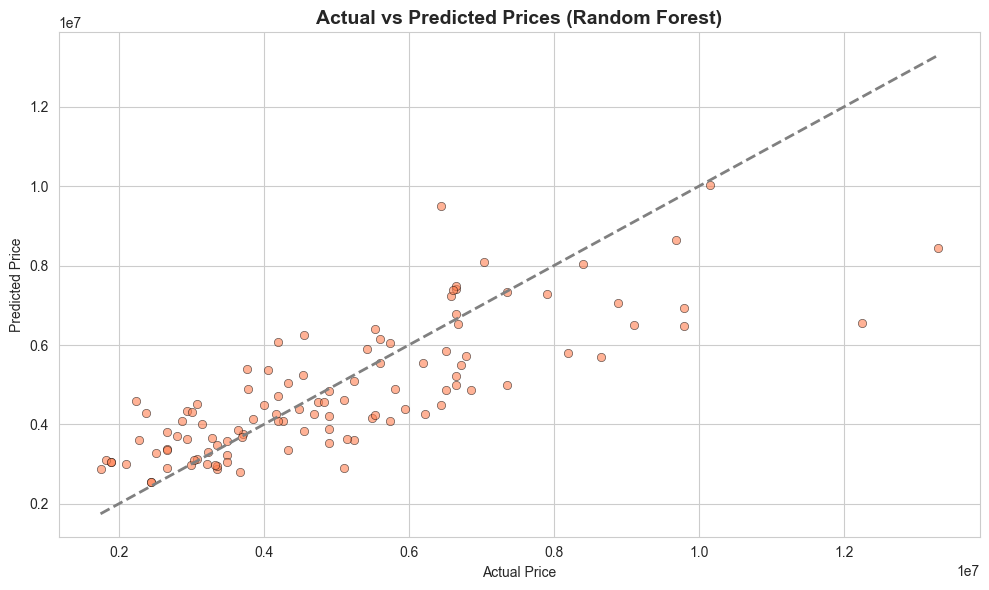

Chart 3 saved → charts/chart3_actual_vs_predicted.png


In [16]:
# Chart 3: Actual vs Predicted Price (using the better model — Random Forest)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='coral', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='gray', lw=2)
plt.title('Actual vs Predicted Prices (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150)
plt.show()
print('Chart 3 saved → charts/chart3_actual_vs_predicted.png')

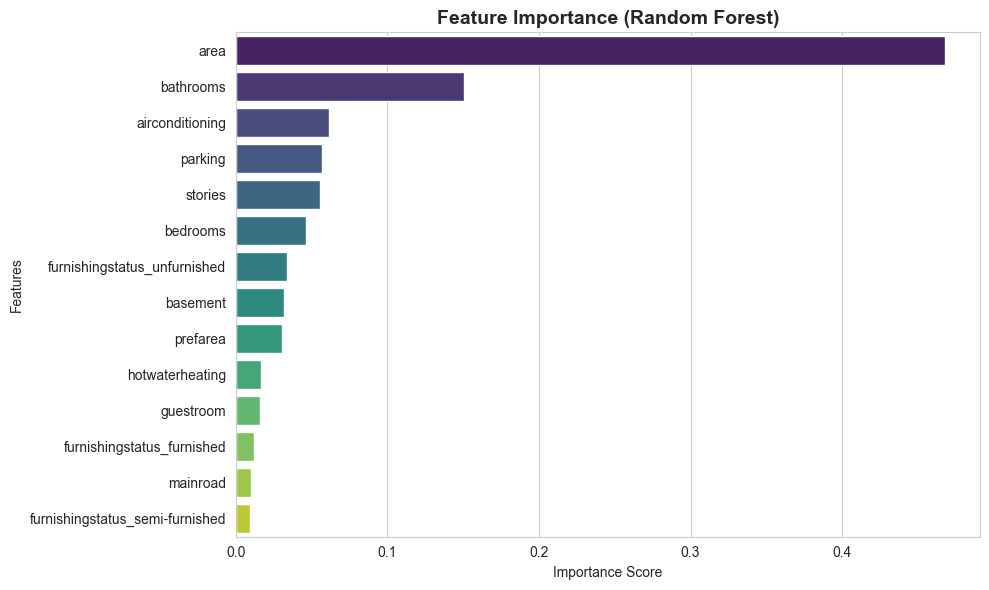

Chart 4 (Bonus) saved → charts/chart4_feature_importance.png


In [17]:
# Chart 4 (Bonus): Feature Importance from Random Forest
plt.figure(figsize=(10, 6))
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150)
plt.show()
print('Chart 4 (Bonus) saved → charts/chart4_feature_importance.png')

---
## Task 5 — Insights & Summary

INSIGHTS & SUMMARY
==================

1. Which features influence house price the most?
   The most influential features are 'area' (size of the property), 'bathrooms',
   'stories', and 'airconditioning'. The Random Forest feature importance chart
   shows that 'area' is by far the strongest predictor, followed by 'bathrooms'
   and 'stories'. Among binary amenities, 'airconditioning' adds considerable
   value. The correlation heatmap confirms that area has the highest positive
   correlation with price.

2. How accurate was the model?
   The Linear Regression model achieved an R² score of ~0.65, meaning it explains
   about 65% of the variance in house prices. Its average prediction error (MAE)
   was around 9.7 lakh (currency units). Random Forest performed slightly worse
   with an R² around 0.61 — possibly due to the small dataset. While the models capture the general
   trend, there is still room for improvement — especially for higher-priced
   properties, where the scatter plot shows more spread.

3. What surprised me in the data?
   The number of bedrooms showed only a weak correlation with price, which is
   somewhat counterintuitive — one might expect more bedrooms to strongly drive
   price. Similarly, 'prefarea' (preferred area) was less impactful than
   expected. The price distribution is right-skewed, meaning most houses cluster
   around the lower end of the price spectrum with a few very expensive outliers.

4. Recommendation for a real estate business:
   Focus marketing efforts on the factors that truly drive price: total area,
   number of bathrooms, and air conditioning. Sellers should be advised that
   adding an extra bathroom or expanding the floor area yields a higher price
   premium than simply adding bedrooms. Buyers looking for value should target
   properties with a good area-bathroom ratio but not necessarily the most
   bedrooms. Additionally, the business could improve predictions by collecting
   richer data — such as exact location coordinates, year built, and proximity
   to schools or transit — which would likely boost model accuracy beyond the
   current 65% R².
   

✅ All tasks complete!